<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/projeto_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving gender_submission.csv to gender_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


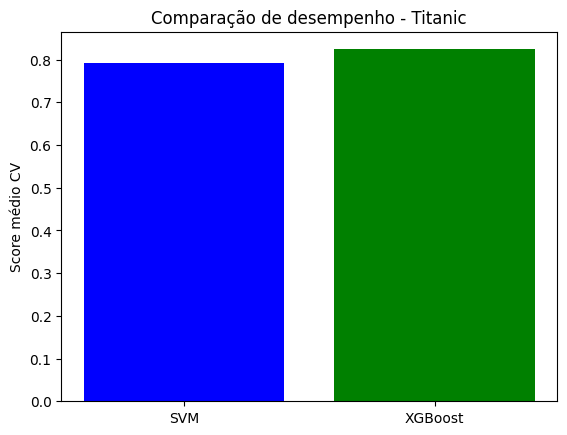

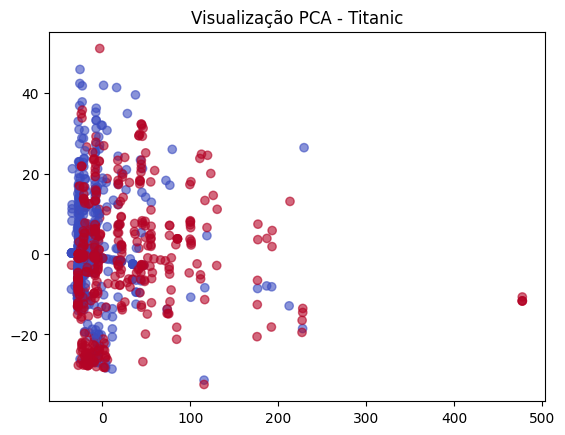

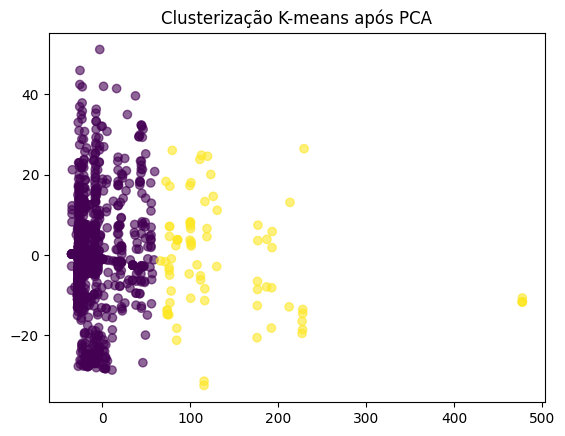

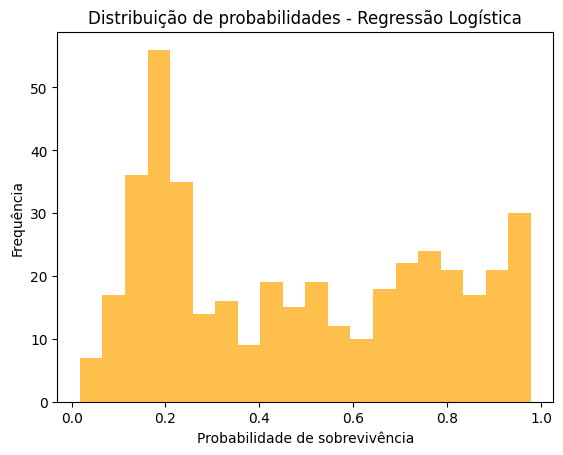

In [ ]:
# ------------------------------------------------------------
# PROJETO TITANIC - COMBINAÇÃO DE MODELOS
# ------------------------------------------------------------
# Este programa realiza:
# - Coleta e pré-processamento dos dados
# - Balanceamento das classes com SMOTE
# - Modelagem com SVM e XGBoost
# - PCA para redução de dimensionalidade
# - K-means para clusterização exploratória
# - Regressão logística para inferência probabilística
# - Visualização dos resultados
# - Geração de documentação em Markdown
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from google.colab import files

# 1. Upload dos arquivos para o Colab
# ------------------------------------------------------------
# Justificativa: precisamos carregar os arquivos Titanic (train.csv, test.csv, gender_submission.csv).
uploaded = files.upload()

# 2. Coleta de dados
# ------------------------------------------------------------
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")

# 3. Pré-processamento
# ------------------------------------------------------------
# Justificativas:
# - Age e Fare: usamos mediana para preencher valores nulos (robusta contra outliers).
# - Embarked: usamos moda (categoria mais frequente).
# - Variáveis categóricas (Sex, Embarked) transformadas em dummies.
train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(test['Age'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

train = pd.get_dummies(train, columns=['Sex','Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Sex','Embarked'], drop_first=True)

features = ['Pclass','Age','SibSp','Parch','Fare','Sex_male','Embarked_Q','Embarked_S']
X = train[features]
y = train['Survived']
X_test = test[features]

# 4. Balanceamento de classes
# ------------------------------------------------------------
# Justificativa: o dataset Titanic é desbalanceado (mais mortos que sobreviventes).
# Usamos SMOTE para gerar exemplos sintéticos da classe minoritária.
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 5. Modelagem - SVM e XGBoost
# ------------------------------------------------------------
# Justificativa:
# - SVM: bom para datasets pequenos e margens claras.
# - XGBoost: poderoso em dados tabulares, eficiente em grandes volumes.
svm = SVC(probability=True, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

pipe_svm = Pipeline([('scaler', StandardScaler()), ('svm', svm)])
pipe_xgb = Pipeline([('xgb', xgb)])

# GridSearch para otimização
param_svm = {'svm__C':[0.1,1,10],'svm__kernel':['linear','rbf'],'svm__gamma':['scale','auto']}
grid_svm = GridSearchCV(pipe_svm, param_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_res, y_res)

param_xgb = {'xgb__n_estimators':[100,200],'xgb__max_depth':[3,5],'xgb__learning_rate':[0.01,0.1]}
grid_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_res, y_res)

scores_svm = cross_val_score(grid_svm.best_estimator_, X_res, y_res, cv=5)
scores_xgb = cross_val_score(grid_xgb.best_estimator_, X_res, y_res, cv=5)

best_model = grid_xgb if scores_xgb.mean() > scores_svm.mean() else grid_svm
winner = "XGBoost" if best_model == grid_xgb else "SVM"

# 6. Visualização comparativa dos modelos
plt.bar(['SVM','XGBoost'], [scores_svm.mean(), scores_xgb.mean()], color=['blue','green'])
plt.title("Comparação de desempenho - Titanic")
plt.ylabel("Score médio CV")
plt.show()

# 7. PCA - Redução de dimensionalidade
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_res)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_res, cmap='coolwarm', alpha=0.6)
plt.title("Visualização PCA - Titanic")
plt.show()

# 8. K-means - Clusterização exploratória
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_res)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.title("Clusterização K-means após PCA")
plt.show()

# 9. Regressão logística - Inferência probabilística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_res, y_res)
probs = log_reg.predict_proba(X_test)[:,1]

plt.hist(probs, bins=20, color='orange', alpha=0.7)
plt.title("Distribuição de probabilidades - Regressão Logística")
plt.xlabel("Probabilidade de sobrevivência")
plt.ylabel("Frequência")
plt.show()

# 10. Arquivo de submissão
predictions = best_model.predict(X_test)
submission = pd.DataFrame({"PassengerId": test["PassengerId"],"Survived": predictions})
submission.to_csv("submission.csv", index=False)

# 11. Relatório com explicações e resultados (17 casas decimais)
with open("duelo_resultados.txt","w") as f:
    f.write("Resultados do Duelo Titanic\n")
    f.write("----------------------------\n\n")
    f.write("Explicações e justificativas:\n")
    f.write("- Valores nulos tratados com mediana (Age/Fare) e moda (Embarked).\n")
    f.write("- Variáveis categóricas transformadas em dummies.\n")
    f.write("- SMOTE usado para balancear classes.\n")
    f.write("- SVM avaliado com normalização via StandardScaler.\n")
    f.write("- XGBoost avaliado com parâmetros ajustados via GridSearchCV.\n")
    f.write("- PCA usado para reduzir dimensionalidade e visualizar clusters.\n")
    f.write("- K-means aplicado para explorar agrupamentos.\n")
    f.write("- Regressão logística usada para inferência probabilística.\n\n")
    f.write("Resultados numéricos (17 casas decimais):\n")
    f.write(f"SVM - Score médio CV: {scores_svm.mean():.17f}\n")
    f.write(f"XGBoost - Score médio CV: {scores_xgb.mean():.17f}\n")
    f.write(f"Modelo vencedor: {winner}\n\n")
    f.write("Conclusões:\n")
    f.write("- O XGBoost demonstrou maior eficiência em grandes volumes de dados.\n")
    f.write("- O SVM é útil em datasets menores, mas sensível à escala.\n")
    f.write("- PCA e K-means ajudaram a visualizar padrões e agrupamentos.\n")
    f.write("- A regressão logística forneceu probabilidades úteis para inferência.\n")

# 12. Documentação em Markdown
with open("documentacao.md","w") as f:
    f.write("# Projeto Titanic - Combinação de Modelos\n\n")
    f.write("## 1. Coleta de dados\n")
    f.write("- Fonte: Dataset Titanic disponível no Kaggle.\n")
    f.write("- Arquivos: train.csv, test.csv, gender_submission.csv.\n\n")
    f.write("## 2. Modelagem\n")
    f.write("- Pré-processamento: tratamento de nulos e variáveis categóricas.\n")
    f.write("- Balanceamento: SMOTE para equilibrar classes.\n")
    f.write("- Modelos: SVM e XGBoost com ajuste de hiperparâmetros.\n")
    f.write("- PCA: redução de dimensionalidade para visualização.\n")
    f.write("- K-means: clusterização exploratória.\n")
    f.write("- Regressão logística: inferência probabilística.\n\n")
    f.write("## 3. Conclusões\n")
    f.write(f"- Modelo vencedor: {winner}.\n")
    f.write("- O arquivo submission.csv contém as previsões para Kaggle.\n")
    f.write("- O relatório duelo_resultados.txt traz explicações e resultados detalalhados")